In [7]:
import pandas as pd
import os

# 1. Define the folder and the 9 files [cite: 101]
folder_path = 'eda'
file_names = [
    'loans_master.csv', 'customer_bureau.csv', 'payment_history.csv',
    'loan_performance.csv', 'monthly_emi_track.csv', 'collateral_assets.csv',
    'branch_region_economy.csv', 'credit_card_behavior.csv', 'loan_enquiry_bureau.csv'
]

# Dictionaries to store our loaded dataframes and memory tracking
dataframes = {}
total_mem_before = 0
total_mem_after = 0
chunk_size = 500_000  # As required to avoid memory overflow [cite: 123]

print("--- Starting Data Loading and Downcasting ---")

# 2. Loop through each file, load in chunks, and downcast
for file in file_names:
    # Combine the folder name with the file name (e.g., 'eda/loans_master.csv')
    file_path = os.path.join(folder_path, file)
    print(f"Processing {file_path}...")
    
    chunks = []
    # Read in chunks to avoid memory overflow [cite: 18, 123]
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        
        # Calculate memory before downcasting
        mem_before = chunk.memory_usage(deep=True).sum()
        total_mem_before += mem_before
        
        # Downcast float64 to float32 and int64 to int32 [cite: 132]
        for col in chunk.columns:
            if chunk[col].dtype == 'float64':
                chunk[col] = chunk[col].astype('float32')
            elif chunk[col].dtype == 'int64':
                chunk[col] = chunk[col].astype('int32')
                
        # Calculate memory after downcasting
        mem_after = chunk.memory_usage(deep=True).sum()
        total_mem_after += mem_after
        
        chunks.append(chunk)
    
    # Concatenate all chunks for this specific table [cite: 18]
    dataframes[file] = pd.concat(chunks, ignore_index=True)

# Print Memory Usage Results
print("\n--- (i) Memory Usage Report ---")
print(f"Total Memory Before Downcasting: {total_mem_before / (1024**2):.2f} MB")
print(f"Total Memory After Downcasting: {total_mem_after / (1024**2):.2f} MB")

# 3. Save to Parquet [cite: 18, 124]
# Saving the first file as an example to get the file size for your Q1(a) answer
test_parquet_name = 'loans_master_downcasted.parquet'
dataframes['loans_master.csv'].to_parquet(test_parquet_name)

# Print File Size Result
file_size_mb = os.path.getsize(test_parquet_name) / (1024**2)
print("\n--- (ii) File Size Report ---")
print(f"File size of the resulting Parquet ({test_parquet_name}): {file_size_mb:.2f} MB")

--- Starting Data Loading and Downcasting ---
Processing eda/loans_master.csv...
Processing eda/customer_bureau.csv...
Processing eda/payment_history.csv...
Processing eda/loan_performance.csv...
Processing eda/monthly_emi_track.csv...
Processing eda/collateral_assets.csv...
Processing eda/branch_region_economy.csv...
Processing eda/credit_card_behavior.csv...
Processing eda/loan_enquiry_bureau.csv...

--- (i) Memory Usage Report ---
Total Memory Before Downcasting: 8246.21 MB
Total Memory After Downcasting: 7200.98 MB

--- (ii) File Size Report ---
File size of the resulting Parquet (loans_master_downcasted.parquet): 60.90 MB


In [ ]:
# b

In [18]:
# 1. Initialize the base dataframe with our primary table (loans_master)
master_df = dataframes['loans_master.csv']
expected_rows = 2_000_000

# Define the order of the remaining 8 tables to merge
tables_to_merge = [
    'customer_bureau.csv', 'payment_history.csv', 'loan_performance.csv', 
    'monthly_emi_track.csv', 'collateral_assets.csv', 'branch_region_economy.csv', 
    'credit_card_behavior.csv', 'loan_enquiry_bureau.csv'
]

total_orphan_records = 0

print("--- Starting Sequential Left Merges ---")

# 2. Loop through and merge sequentially
for table_name in tables_to_merge:
    right_df = dataframes[table_name]
    
    # Calculate Orphan Records: 
    # Find 'loan_id's that exist in the right table but NOT in the master table
    orphans = len(set(right_df['loan_id']) - set(master_df['loan_id']))
    total_orphan_records += orphans
    # Perform the Left Merge
    master_df = master_df.merge(right_df, on='loan_id', how='left')
    
    # Assert that the row count is exactly 2,000,000
    try:
        assert master_df.shape[0] == expected_rows
        print(f"Merged {table_name} successfully. Row count validated: {master_df.shape[0]}. Orphans found: {orphans}")
    except AssertionError:
        print(f"ERROR: Row count violated after merging {table_name}! Count is now: {master_df.shape[0]}")

print("\n--- Final Merge Summary ---")
print(f"Final merged dataset shape: {master_df.shape}")
print(f"Total orphan records detected: {total_orphan_records}")

--- Starting Sequential Left Merges ---
total0
Merged customer_bureau.csv successfully. Row count validated: 2000000. Orphans found: 0
total0
Merged payment_history.csv successfully. Row count validated: 2000000. Orphans found: 0
total0
Merged loan_performance.csv successfully. Row count validated: 2000000. Orphans found: 0
total0
Merged monthly_emi_track.csv successfully. Row count validated: 2000000. Orphans found: 0
total0
Merged collateral_assets.csv successfully. Row count validated: 2000000. Orphans found: 0
total0
Merged branch_region_economy.csv successfully. Row count validated: 2000000. Orphans found: 0
total0
Merged credit_card_behavior.csv successfully. Row count validated: 2000000. Orphans found: 0
total0
Merged loan_enquiry_bureau.csv successfully. Row count validated: 2000000. Orphans found: 0

--- Final Merge Summary ---
Final merged dataset shape: (2000000, 182)
Total orphan records detected: 0


In [11]:
print(master_df)

             loan_id issue_date  issue_year  issue_month  loan_amnt_inr  \
0        LN000000001   Feb-2016        2016            2        80678.0   
1        LN000000002   May-2024        2024            5       274166.0   
2        LN000000003   Dec-2021        2021           12        59603.0   
3        LN000000004   Nov-2020        2020           11       246313.0   
4        LN000000005   Jul-2013        2013            7       101471.0   
...              ...        ...         ...          ...            ...   
1999995  LN001999996   Oct-2018        2018           10        85677.0   
1999996  LN001999997   Apr-2023        2023            4        72216.0   
1999997  LN001999998   Oct-2021        2021           10        52596.0   
1999998  LN001999999   Feb-2016        2016            2        97617.0   
1999999  LN002000000   Jul-2021        2021            7       313106.0   

         funded_amnt_inr  loan_term_months  int_rate_pct  installment_inr  \
0                74992

In [12]:
# 1 (c)
import numpy as np
from sklearn.impute import SimpleImputer, KNNImputer

In [20]:
#Issue 1: Create the binary column
master_df['dirty_flag'] = 0

In [21]:
# Identify negative interest rates and flag them
master_df.loc[master_df['int_rate_pct'] < 0, 'dirty_flag'] = 1

In [22]:
# Calculate the median interest rate for every single row based on its grade
grade_medians = master_df.groupby('grade')['int_rate_pct'].transform('median')

# Find the rows where the interest rate is negative, and replace them with those medians
master_df.loc[master_df['int_rate_pct'] < 0, 'int_rate_pct'] = grade_medians

In [23]:
# Issue 2:1. Calculate the median income based on the borrower's job title
title_medians = master_df.groupby('emp_title')['annual_inc_inr'].transform('median')

In [24]:
# 2. Flag the rows where income is exactly 0
master_df.loc[master_df['annual_inc_inr'] == 0, 'dirty_flag'] = 1

In [25]:
# 3. Replace the 0s with the normal job title median we calculated above
master_df.loc[master_df['annual_inc_inr'] == 0, 'annual_inc_inr'] = title_medians

In [27]:
#Issue 3: Impossible DTI (Debt-to-Income Ratio)
# 1. Calculate the median DTI based on the loan grade
grade_dti_medians = master_df.groupby('grade')['dti_pct'].transform('median')

In [28]:
# 2. Flag the rows where DTI is exactly 999
master_df.loc[master_df['dti_pct'] == 999, 'dirty_flag'] = 1

In [29]:
# 3. Replace the 999s with the normal grade median we calculated above
master_df.loc[master_df['dti_pct'] == 999, 'dti_pct'] = grade_dti_medians

In [37]:
#Issue 4: Negative Revolving Utilization
count = (master_df['revol_util_pct'] < 0).sum()
print(f"Rows with revol_util_pct < 0: {count}")

Rows with revol_util_pct < 0: 0


In [38]:
# 1. Flag the rows where revolving utilization is less than 0
master_df.loc[master_df['revol_util_pct'] < 0, 'dirty_flag'] = 1

In [40]:
# 2. Fix the error by taking the absolute value (turning negatives into positives)
master_df['revol_util_pct'] = master_df['revol_util_pct'].abs()

In [44]:
#Issue 5: Missing Values in Months Since Last Delinquency
# 1. We don't need to use the dirty_flag for missing values, just fix them directly.
# Replace all the blank (NaN) spaces with the number 999
master_df['mths_since_last_delinq'] = master_df['mths_since_last_delinq'].fillna(999)

In [42]:
#Issue 6: High Missing Values in Mortgage Accounts
# 1. Find the most common number (the mode) in the mort_acc column
# [0] grabs the first most common number, which is usually 0
most_common_mort = master_df['mort_acc'].mode()[0]

In [45]:
# 2. Fill all the blank (NaN) spaces with that number
master_df['mort_acc'] = master_df['mort_acc'].fillna(most_common_mort)

In [46]:
#Issue 7: Missing Values in Employment Length
# 1. Figure out the normal (median) employment length for every specific job title
title_emp_medians = master_df.groupby('emp_title')['emp_length_years'].transform('median')

In [48]:
# 2. Fill the blank (NaN) spaces with those specific medians
master_df['emp_length_years'] = master_df['emp_length_years'].fillna(title_emp_medians)

In [49]:
# 3. Safety check: If a rare job title was completely blank for everyone, fill remaining blanks with the overall median
overall_median = master_df['emp_length_years'].median()
master_df['emp_length_years'] = master_df['emp_length_years'].fillna(overall_median)

In [52]:
#Issue 8: Moderate Missing Values in Installment Loan Utilization

from sklearn.impute import KNNImputer

print("Starting optimized KNN Imputation...")

# 1. Set up the KNN Imputer
knn = KNNImputer(n_neighbors=5)

# 2. Grab a small random sample of 1,000 valid rows to "train" the imputer fast
valid_data = master_df[['il_util_pct']].dropna().sample(n=1000, random_state=42)
knn.fit(valid_data)

# 3. Find exactly where the missing values are
missing_mask = master_df['il_util_pct'].isnull()

# 4. Use the trained KNN to quickly predict ONLY the missing rows
missing_data = master_df.loc[missing_mask, ['il_util_pct']]
master_df.loc[missing_mask, 'il_util_pct'] = knn.transform(missing_data)

print("Issue 8 complete! Missing values filled successfully.")

Starting optimized KNN Imputation...
Issue 8 complete! Missing values filled successfully.


In [53]:
# E : 


In [59]:
import pandas as pd

# 1. Update this list if you found the new spelling in Step 1!
skewed_cols = [
    'revol_bal_inr', 'mort_acc', 'avg_cur_bal_inr', 'total_cc_balance_inr'
]

summary_data = []

print("Starting Winsorization...")

# 2. Only run the loop for columns that ACTUALLY exist in your dataframe
for col in skewed_cols:
    if col not in master_df.columns:
        print(f"⚠️ SKIPPED: Column '{col}' not found in dataframe. Check spelling!")
        continue # Skip to the next column
        
    # Record BEFORE statistics
    mean_before = master_df[col].mean()
    std_before = master_df[col].std()
    max_before = master_df[col].max()
    
    # Find the 1st and 99th percentile limits
    p01 = master_df[col].quantile(0.01)
    p99 = master_df[col].quantile(0.99)
    
    # WINSORIZE: Cap the extreme highs and lows
    master_df[col] = master_df[col].clip(lower=p01, upper=p99)
    
    # Record AFTER statistics
    mean_after = master_df[col].mean()
    std_after = master_df[col].std()
    max_after = master_df[col].max()
    
    # Save the results for the table
    summary_data.append({
        'Feature': col,
        'Mean (Before)': round(mean_before, 2),
        'Mean (After)': round(mean_after, 2),
        'Std Dev (Before)': round(std_before, 2),
        'Std Dev (After)': round(std_after, 2),
        'Max (Before)': round(max_before, 2),
        'Max (After)': round(max_after, 2)
    })

# 3. Display the final Summary Table
summary_df = pd.DataFrame(summary_data)
display(summary_df)

Starting Winsorization...


,Feature,Mean (Before),Mean (After),Std Dev (Before),Std Dev (After),Max (Before),Max (After)
0,revol_bal_inr,27437.679688,26072.190000,48713.42,35993.60,3000000.00,218004.78
1,mort_acc,1.050000,1.050000,1.28,1.28,5.00,5.00
2,avg_cur_bal_inr,3738.270020,3284.090088,12547.08,6600.88,2434032.75,44733.44
3,total_cc_balance_inr,44042.679688,42899.320000,73096.96,66011.46,986450.00,366026.05


In [60]:
# QUESTION 2   EXPLORATORY DATA ANALYSIS

Exact Default Rate: 3.88%
Performing Rate: 96.12%


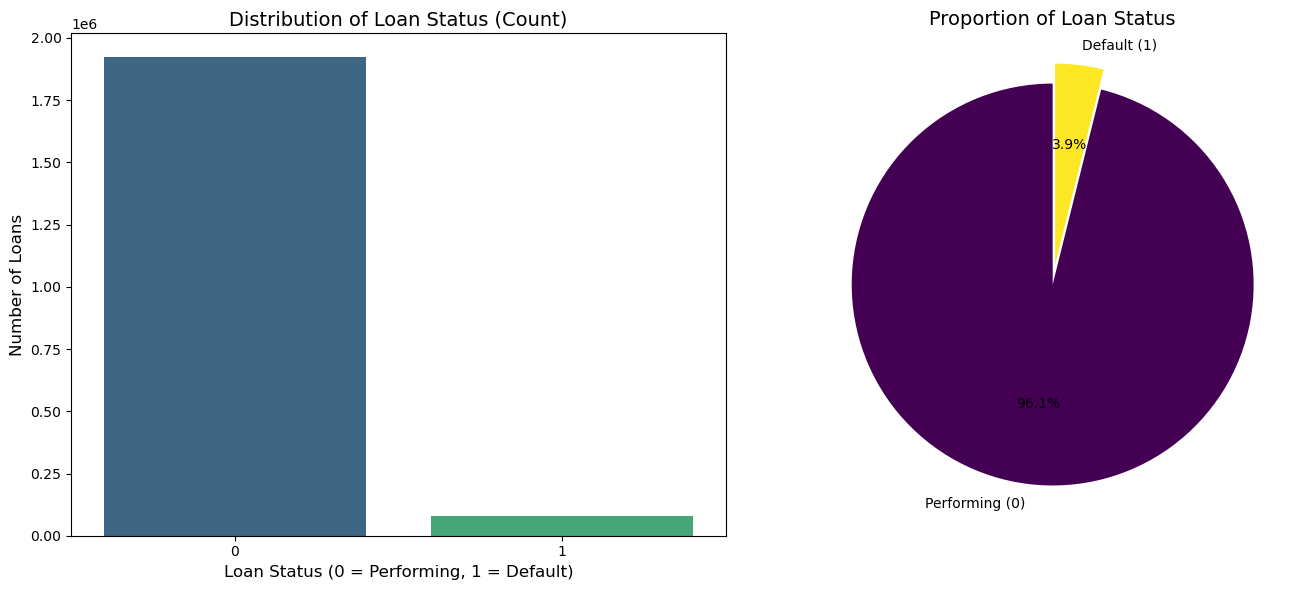

In [65]:
# a
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the exact percentages
status_counts = master_df['loan_status'].value_counts()
status_pct = master_df['loan_status'].value_counts(normalize=True) * 100

exact_default_rate = status_pct[1]
print(f"Exact Default Rate: {exact_default_rate:.2f}%")
print(f"Performing Rate: {status_pct[0]:.2f}%")

# 2. Set up the figure for two side-by-side charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Chart 1: Bar Chart ---
sns.countplot(data=master_df, x='loan_status', ax=axes[0], palette='viridis')
axes[0].set_title('Distribution of Loan Status (Count)', fontsize=14)
axes[0].set_xlabel('Loan Status (0 = Performing, 1 = Default)', fontsize=12)
axes[0].set_ylabel('Number of Loans', fontsize=12)

# --- Chart 2: Pie Chart ---
axes[1].pie(status_counts, labels=['Performing (0)', 'Default (1)'], autopct='%1.1f%%', 
            colors=['#440154', '#fde725'], startangle=90, explode=(0, 0.1))
axes[1].set_title('Proportion of Loan Status', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
# b

In [67]:
# 1. Separate the CIBIL scores by loan status
perf_cibil = master_df[master_df['loan_status'] == 0]['cibil_score'].dropna()
def_cibil = master_df[master_df['loan_status'] == 1]['cibil_score'].dropna()

In [68]:
# 2. Calculate Means
mean_perf = perf_cibil.mean()
mean_def = def_cibil.mean()

In [70]:
# 4. Calculate Empirical Distributional Overlap
bins = np.linspace(300, 900, 100)
hist_perf, _ = np.histogram(perf_cibil, bins=bins, density=True)
hist_def, _ = np.histogram(def_cibil, bins=bins, density=True)
overlap_pct = np.sum(np.minimum(hist_perf, hist_def)) * (bins[1] - bins[0]) * 100

In [71]:
# Print the required metrics
print(f"Mean CIBIL (Performing): {mean_perf:.2f}")
print(f"Mean CIBIL (Defaulted): {mean_def:.2f}")
print(f"Cohen's d: {cohens_d:.2f}")
print(f"Distributional Overlap: {overlap_pct:.2f}%")

Mean CIBIL (Performing): 680.68
Mean CIBIL (Defaulted): 660.11
Cohen's d: 0.24
Distributional Overlap: 90.35%


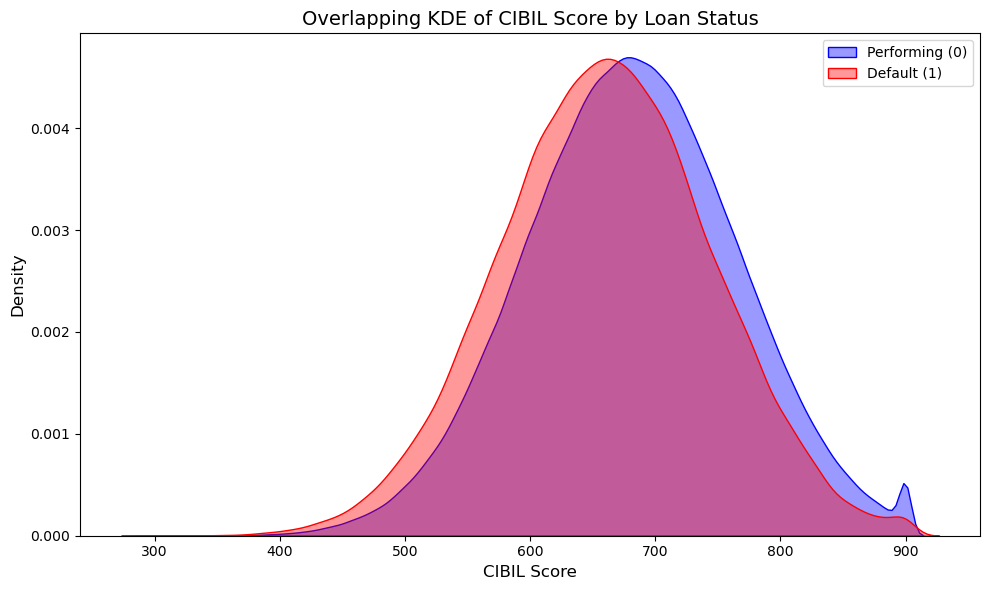

In [72]:
# 5. Plot the overlapping KDE curves
plt.figure(figsize=(10, 6))
sns.kdeplot(perf_cibil, label='Performing (0)', fill=True, color='blue', alpha=0.4)
sns.kdeplot(def_cibil, label='Default (1)', fill=True, color='red', alpha=0.4)

plt.title('Overlapping KDE of CIBIL Score by Loan Status', fontsize=14)
plt.xlabel('CIBIL Score', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# c

In [77]:
# 1. Define the 12 key numeric features using your EXACT column names
numeric_features = [
    'loan_amnt_inr', 'int_rate_pct', 'annual_inc_inr', 'dti_pct', 
    'cibil_score', 'emp_length_years', 'revol_util_pct', 'revol_bal_inr', 
    'total_acc', 'mort_acc', 'avg_cur_bal_inr', 'total_cc_balance_inr'
]

In [78]:
# 2. Check initial skewness
print("--- Initial Skewness ---")
initial_skew = master_df[numeric_features].skew()
print(initial_skew)


--- Initial Skewness ---
loan_amnt_inr           3.651117
int_rate_pct            0.590027
annual_inc_inr          4.675825
dti_pct                 0.597136
cibil_score            -0.034678
emp_length_years        1.939471
revol_util_pct          0.287196
revol_bal_inr           3.063568
total_acc               0.000877
mort_acc                1.131318
avg_cur_bal_inr         4.212462
total_cc_balance_inr    2.682323
dtype: float64


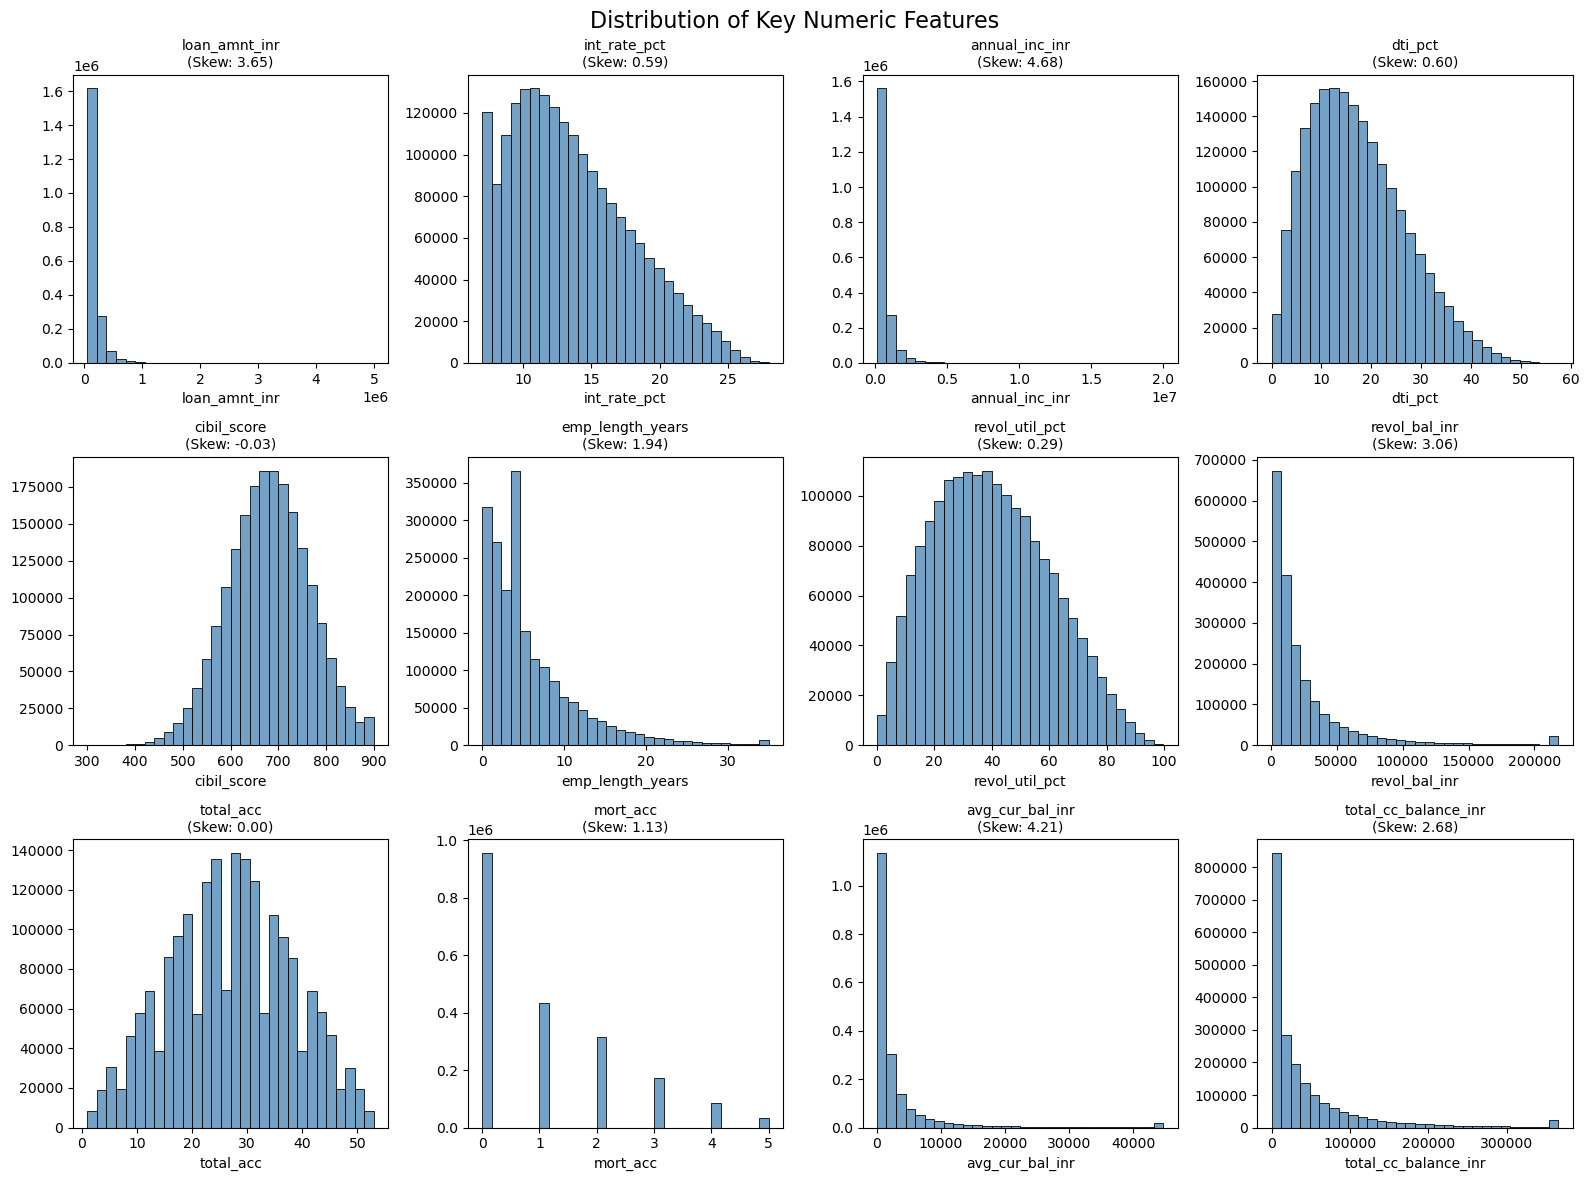

In [79]:
# 3. Plot the 12-panel histogram grid
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Distribution of Key Numeric Features', fontsize=16)

for i, col in enumerate(numeric_features):
    row, col_idx = divmod(i, 4)
    sns.histplot(master_df[col].dropna(), bins=30, ax=axes[row, col_idx], color='steelblue')
    axes[row, col_idx].set_title(f'{col}\n(Skew: {initial_skew[col]:.2f})', fontsize=10)
    axes[row, col_idx].set_ylabel('')

plt.tight_layout()
plt.show()

In [80]:
# 4. Apply Log Transformation (log(1+x)) to the two most skewed features
master_df['log_annual_inc'] = np.log1p(master_df['annual_inc_inr'])
master_df['log_loan_amnt'] = np.log1p(master_df['loan_amnt_inr'])

In [81]:
# 5. Confirm skew reduction
print("\n--- Skewness AFTER Log Transformation ---")
print(f"log_annual_inc skew: {master_df['log_annual_inc'].skew():.2f}")
print(f"log_loan_amnt skew: {master_df['log_loan_amnt'].skew():.2f}")


--- Skewness AFTER Log Transformation ---
log_annual_inc skew: 0.33
log_loan_amnt skew: 0.58


In [82]:
# d

In [83]:
# 1. Grab the top 20 numeric features (excluding ID/dirty flags)
numeric_df = master_df.select_dtypes(include=[np.number])
cols_to_drop = [col for col in numeric_df.columns if 'id' in col.lower() or 'flag' in col.lower() or 'loan_status' in col]
numeric_df = numeric_df.drop(columns=cols_to_drop, errors='ignore')

In [84]:
# Get the first 20 valid numeric columns
top_20_cols = numeric_df.columns[:20]

In [85]:
# 2. Compute Pearson correlation matrix
corr_matrix = master_df[top_20_cols].corr()

In [86]:
# 3. Find specific pairs where correlation is > 0.75 or < -0.75
print("--- Highly Correlated Pairs (|r| > 0.75) ---")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.75:
            colname1 = corr_matrix.columns[i]
            colname2 = corr_matrix.columns[j]
            corr_val = corr_matrix.iloc[i, j]
            print(f"{colname1} and {colname2}: {corr_val:.2f}")

--- Highly Correlated Pairs (|r| > 0.75) ---
funded_amnt_inr and loan_amnt_inr: 1.00
installment_inr and loan_amnt_inr: 0.84
installment_inr and funded_amnt_inr: 0.84
annual_installment_inr and loan_amnt_inr: 0.84
annual_installment_inr and funded_amnt_inr: 0.84
annual_installment_inr and installment_inr: 1.00
rate_spread_pct and int_rate_pct: 0.97
real_interest_rate_pct and int_rate_pct: 0.91
real_interest_rate_pct and rate_spread_pct: 0.91


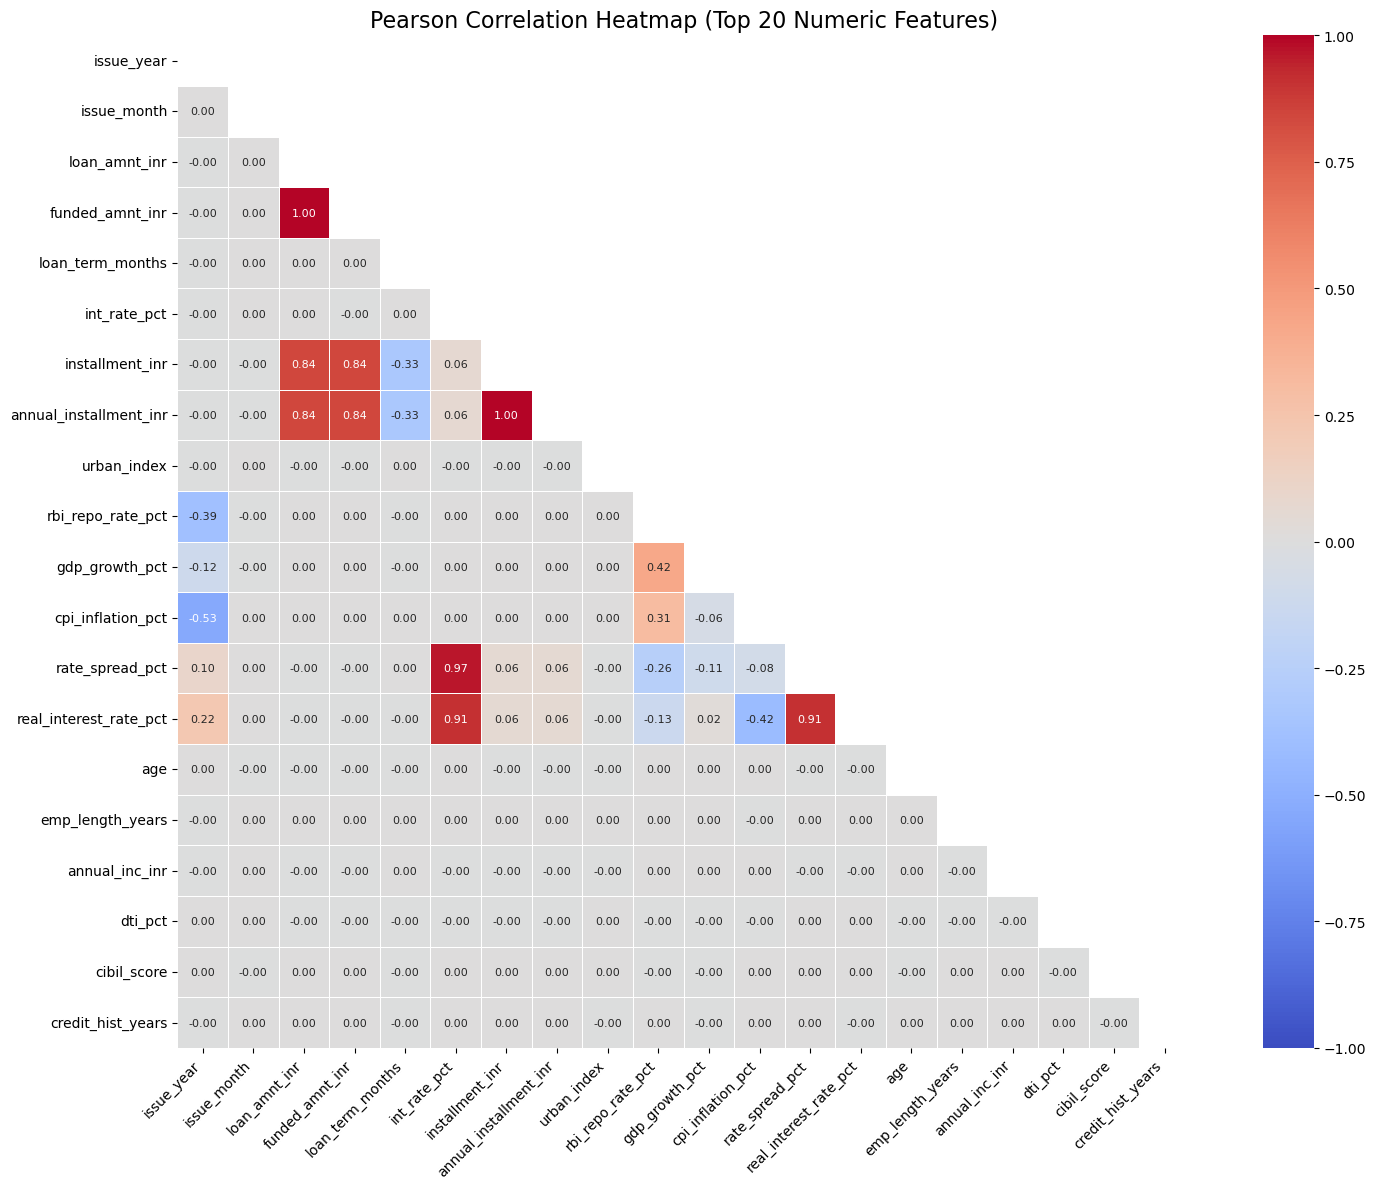

In [87]:
# 4. Plot the Heatmap
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            vmin=-1, vmax=1, square=True, linewidths=.5, annot_kws={"size": 8})

plt.title('Pearson Correlation Heatmap (Top 20 Numeric Features)', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# E

In [88]:
# 1. Define the 6 specific features requested
features = [
    'int_rate_pct', 'dti_pct', 'cibil_score', 
    'annual_inc_inr', 'revol_util_pct', 'emp_length_years'
]

# Ensure columns exist to prevent crashes
features = [f for f in features if f in master_df.columns]

In [89]:
# 2. Calculate and print the exact median differences
print("--- Median Differences (Default vs Performing) ---")
for f in features:
    median_perf = master_df[master_df['loan_status'] == 0][f].median()
    median_def = master_df[master_df['loan_status'] == 1][f].median()
    diff = abs(median_perf - median_def)
    print(f"{f}: Difference = {diff:.2f}")

--- Median Differences (Default vs Performing) ---
int_rate_pct: Difference = 2.47
dti_pct: Difference = 4.44
cibil_score: Difference = 21.00
annual_inc_inr: Difference = 3463.00
revol_util_pct: Difference = 0.80
emp_length_years: Difference = 0.00


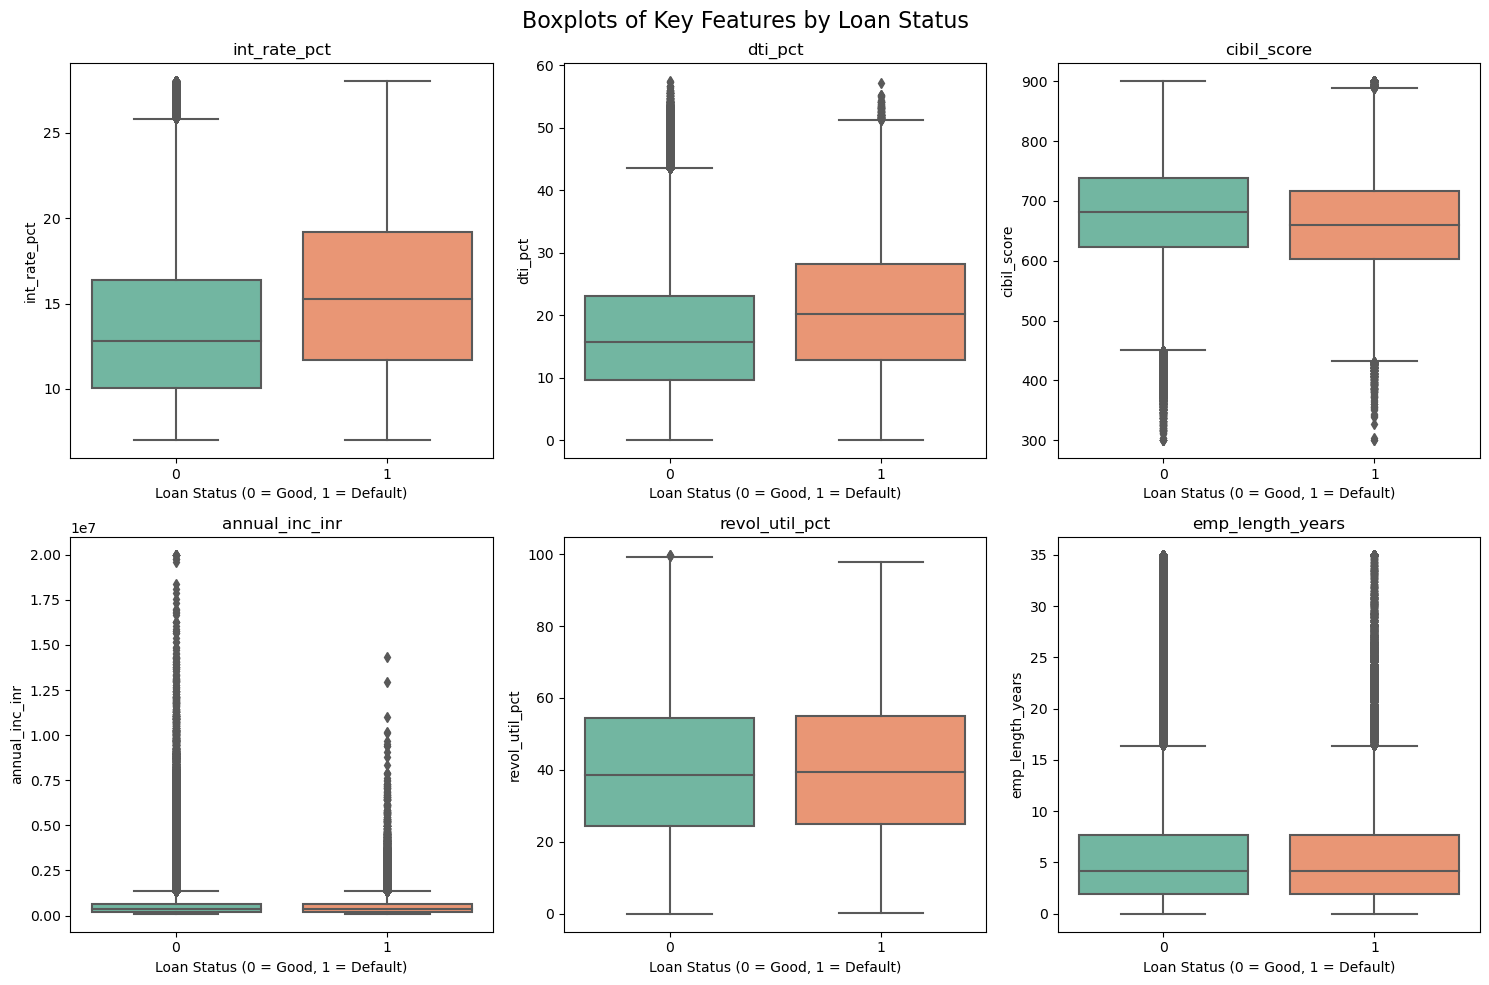

In [90]:
# 3. Plot the 6 side-by-side boxplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Boxplots of Key Features by Loan Status', fontsize=16)

# Flatten axes for easy looping
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x='loan_status', y=col, data=master_df, ax=axes[i], palette='Set2')
    axes[i].set_title(col)
    axes[i].set_xlabel('Loan Status (0 = Good, 1 = Default)')

plt.tight_layout()
plt.show()

In [ ]:
# f

In [91]:
# 1. Calculate the default rate (%) for each loan grade (A to G)
grade_rates = master_df.groupby('grade')['loan_status'].mean() * 100
grade_rates = grade_rates.sort_index()

In [92]:
# 2. Check if it is monotonically ordered (always goes up step-by-step)
is_monotonic = grade_rates.is_monotonic_increasing

In [93]:
# 3. Find the differences (jumps) between each grade
jumps = grade_rates.diff()
max_jump = jumps.max()
grade_after_jump = jumps.idxmax()

# Find the grade right before the big jump
grades_list = grade_rates.index.tolist()
grade_before_jump = grades_list[grades_list.index(grade_after_jump) - 1]

# Print the exact answers you need for your exam paper
print(f"Monotonically Ordered: {'Yes' if is_monotonic else 'No'}")
print(f"Largest Jump: Grade {grade_before_jump} to Grade {grade_after_jump}")
print(f"Jump Size: {max_jump:.2f} percentage points")

Monotonically Ordered: Yes
Largest Jump: Grade F to Grade G
Jump Size: 2.05 percentage points


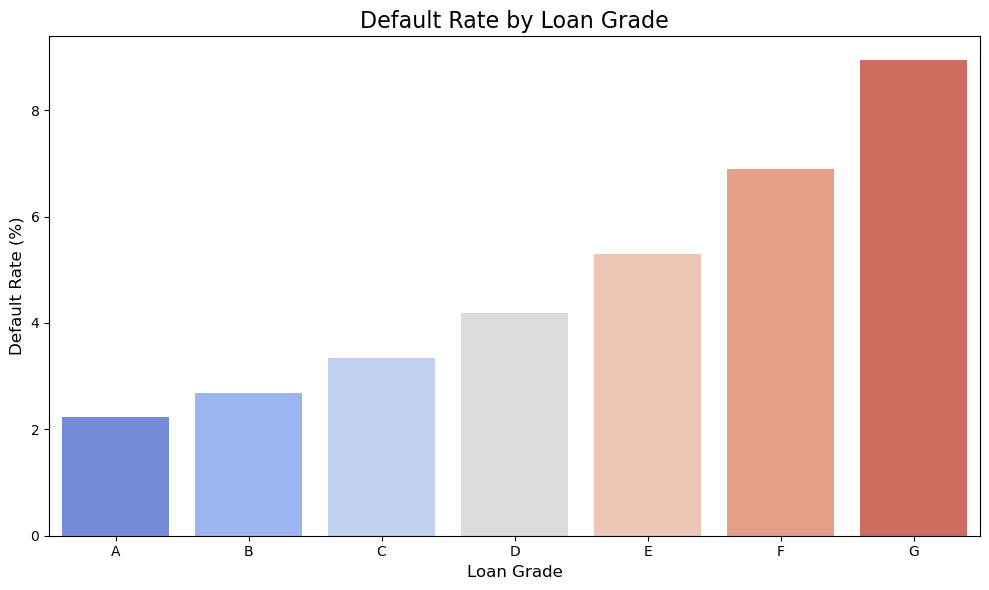

In [94]:
# 4. Plot the Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x=grade_rates.index, y=grade_rates.values, palette='coolwarm')

plt.title('Default Rate by Loan Grade', fontsize=16)
plt.xlabel('Loan Grade', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# g

In [97]:
# 1. Calculate the default rate (%) for each loan purpose
purpose_rates = master_df.groupby('loan_purpose')['loan_status'].mean() * 100

# Sort the rates from highest risk to lowest risk
purpose_rates = purpose_rates.sort_values(ascending=False)

In [98]:
# 2. Find the top 3 highest and bottom 2 lowest risk purposes
top_3_risk = purpose_rates.head(3)
bottom_2_risk = purpose_rates.tail(2)

In [100]:
# 3. Calculate the ratio between the highest and lowest
highest_rate = purpose_rates.iloc[0]
lowest_rate = purpose_rates.iloc[-1]
risk_ratio = highest_rate / lowest_rate

# Print the answers for your exam paper
print("--- 3 Highest-Risk Purposes ---")
print(top_3_risk.round(2))
print("\n--- 2 Lowest-Risk Purposes ---")
print(bottom_2_risk.round(2))
print(f"\nRisk Ratio (Highest/Lowest): {risk_ratio:.2f}x")

--- 3 Highest-Risk Purposes ---
loan_purpose
major_purchase    4.01
car               3.91
small_business    3.91
Name: loan_status, dtype: float64

--- 2 Lowest-Risk Purposes ---
loan_purpose
moving       3.8
education    3.8
Name: loan_status, dtype: float64

Risk Ratio (Highest/Lowest): 1.05x


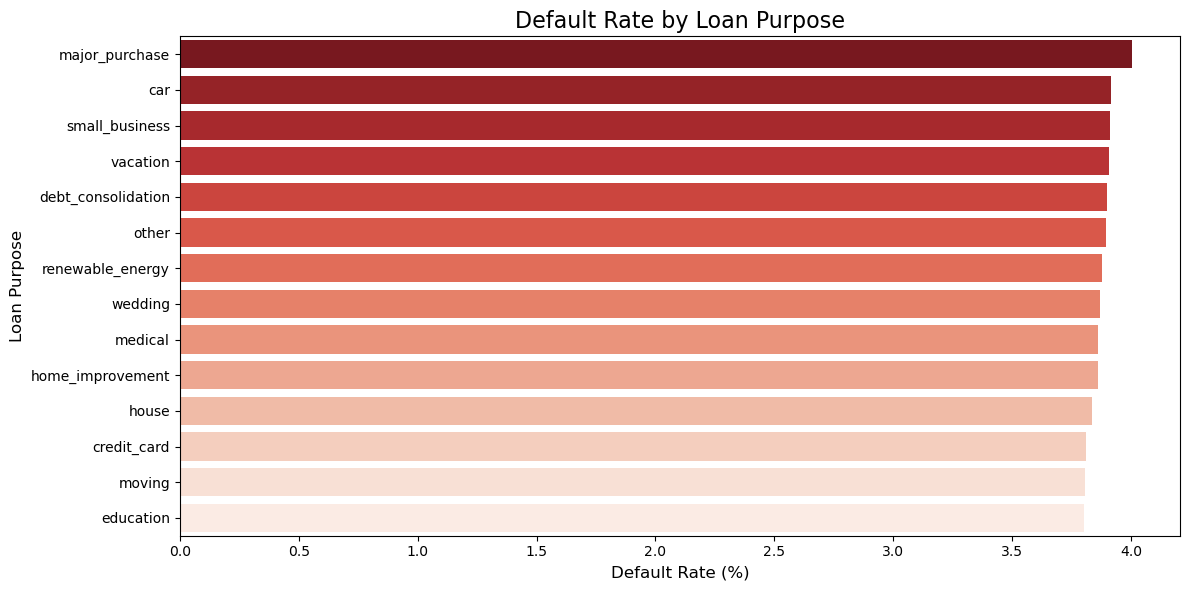

In [101]:
# 4. Plot the Horizontal Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(x=purpose_rates.values, y=purpose_rates.index, palette='Reds_r')

plt.title('Default Rate by Loan Purpose', fontsize=16)
plt.xlabel('Default Rate (%)', fontsize=12)
plt.ylabel('Loan Purpose', fontsize=12)

plt.tight_layout()
plt.show()

In [102]:
# h

In [103]:
# 1. Find the exact state column name (usually 'addr_state' or 'state')
state_col = [col for col in master_df.columns if 'state' in col.lower()][0]

In [104]:
# 2. Calculate the Bank-Wide Average Default Rate
bank_avg = master_df['loan_status'].mean() * 100
threshold = bank_avg + 5.0  # The +5% danger zone

In [105]:
# 3. Calculate Default Rates by State and get Top 10
state_rates = master_df.groupby(state_col)['loan_status'].mean() * 100
top_10_states = state_rates.sort_values(ascending=False).head(10)

In [110]:
# 4. Flag states that exceed the bank average by more than 5%
flagged_states = top_10_states[top_10_states > threshold]

# Print the exact numbers for your written answer
print(f"Bank Average: {bank_avg:.2f}% | Danger Threshold: {threshold:.2f}%")
print("\n--- Top 10 States ---")
print(top_10_states.round(2))
print("\n--- Flagged States (>5% above average) ---")
print("None" if flagged_states.empty else flagged_states.round(2))

Bank Average: 3.88% | Danger Threshold: 8.88%

--- Top 10 States ---
state_code
BR    4.07
OR    4.01
UP    3.98
PB    3.97
UK    3.96
HP    3.92
MP    3.92
TN    3.91
AP    3.89
TG    3.89
Name: loan_status, dtype: float64

--- Flagged States (>5% above average) ---
None


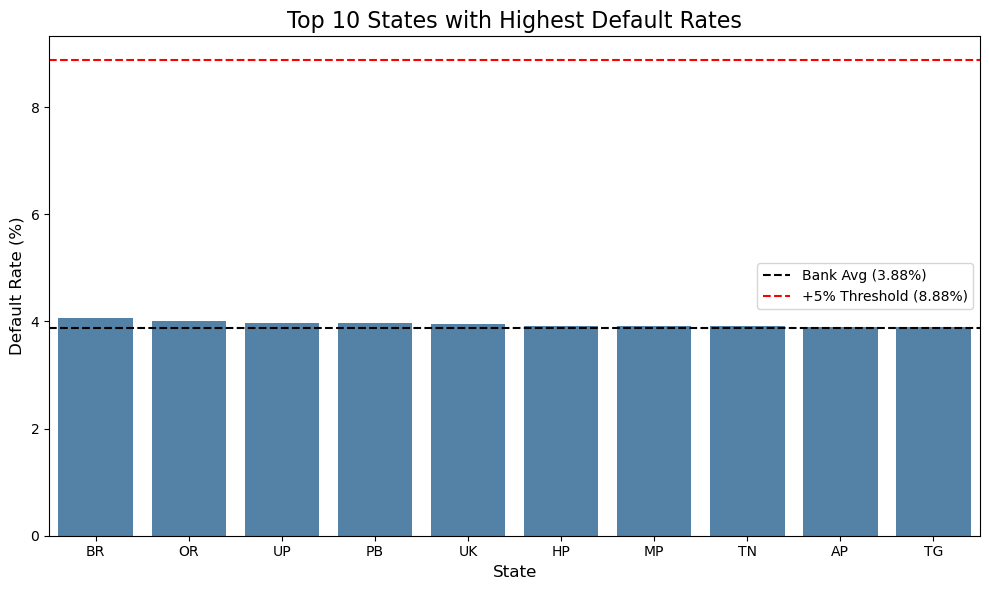

In [111]:
# 5. Plot the Bar Chart
plt.figure(figsize=(10, 6))

# Color flagged states red, and normal states blue
colors = ['red' if val > threshold else 'steelblue' for val in top_10_states.values]
sns.barplot(x=top_10_states.index, y=top_10_states.values, palette=colors)

# Draw lines to show the average and the danger threshold
plt.axhline(bank_avg, color='black', linestyle='--', label=f'Bank Avg ({bank_avg:.2f}%)')
plt.axhline(threshold, color='red', linestyle='--', label=f'+5% Threshold ({threshold:.2f}%)')

plt.title('Top 10 States with Highest Default Rates', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

In [112]:
# i

In [113]:
# 1. Find the date/year column (usually named 'issue_d', 'year', or similar)
date_col = [col for col in master_df.columns if 'issue' in col.lower() or 'year' in col.lower() or 'date' in col.lower()][0]

# Safely extract just the year
if not pd.api.types.is_numeric_dtype(master_df[date_col]):
    master_df['issue_year'] = pd.to_datetime(master_df[date_col]).dt.year
else:
    master_df['issue_year'] = master_df[date_col]

/var/folders/wq/qny254f95pzb62gc0tkv2vcc0000gn/T/ipykernel_1722/809565943.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  master_df['issue_year'] = pd.to_datetime(master_df[date_col]).dt.year


In [114]:
# 2. Calculate the Annual Default Rate (%)
annual_rates = master_df.groupby('issue_year')['loan_status'].mean() * 100

# Filter for the requested timeframe: 2010 to 2024
annual_rates = annual_rates[(annual_rates.index >= 2010) & (annual_rates.index <= 2024)]

In [115]:
# 3. Quantify the COVID-19 Shock (2019 vs 2020)
if 2019 in annual_rates and 2020 in annual_rates:
    rate_2019 = annual_rates.loc[2019]
    rate_2020 = annual_rates.loc[2020]
    
    # Calculate how much it jumped mathematically
    pct_increase = ((rate_2020 - rate_2019) / rate_2019) * 100
    
    print(f"2019 Default Rate: {rate_2019:.2f}%")
    print(f"2020 Default Rate: {rate_2020:.2f}%")
    print(f"Percentage Increase: {pct_increase:.2f}%")
else:
    print("Warning: 2019 or 2020 data is missing from the dataset.")

2019 Default Rate: 4.13%
2020 Default Rate: 4.46%
Percentage Increase: 8.10%


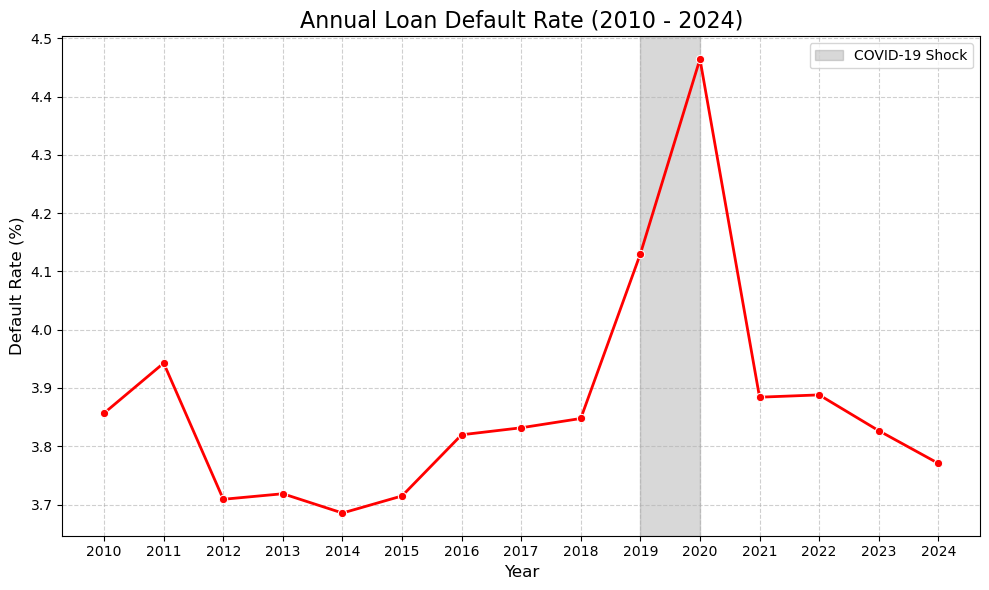

In [116]:
# 4. Plot the Line Chart
plt.figure(figsize=(10, 6))
sns.lineplot(x=annual_rates.index, y=annual_rates.values, marker='o', color='red', linewidth=2)

# Highlight the COVID-19 shock area (2019 to 2020)
plt.axvspan(2019, 2020, color='gray', alpha=0.3, label='COVID-19 Shock')

plt.title('Annual Loan Default Rate (2010 - 2024)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Default Rate (%)', fontsize=12)
plt.xticks(range(2010, 2025)) # Show every year on the bottom
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [117]:
# j

In [120]:
# 1. Group the data by year to get both the Default Rate and the Average Repo Rate
annual_data = master_df.groupby('issue_year').agg(
    default_rate=('loan_status', lambda x: x.mean() * 100),
    repo_rate=('rbi_repo_rate_pct', 'mean')
).dropna()

In [121]:
# 2. Calculate the correlation to find the "Lag" (Delay)
print("--- Finding the Lag (Correlation) ---")
best_lag = 0
highest_corr = -1

for lag in range(4):
    # Shift the repo rate forward to see when it impacts defaults the most
    corr = annual_data['repo_rate'].shift(lag).corr(annual_data['default_rate'])
    print(f"Lag of {lag} Years -> Correlation: {corr:.2f}")
    if corr > highest_corr:
        highest_corr = corr
        best_lag = lag

print(f"\nEstimated Lag: {best_lag} Years")

--- Finding the Lag (Correlation) ---
Lag of 0 Years -> Correlation: -0.75
Lag of 1 Years -> Correlation: -0.48
Lag of 2 Years -> Correlation: -0.12
Lag of 3 Years -> Correlation: -0.05

Estimated Lag: 3 Years


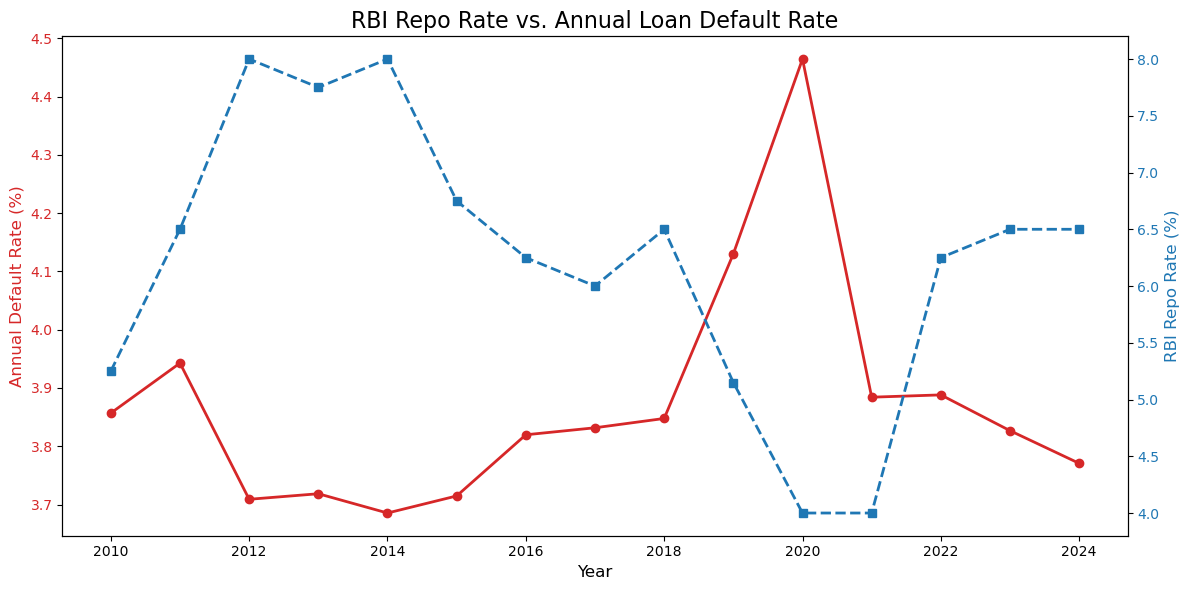

In [122]:
# 3. Plot the Dual-Axis Line Chart
fig, ax1 = plt.subplots(figsize=(12, 6))

# Left Axis: Default Rate (Red)
color1 = 'tab:red'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Annual Default Rate (%)', color=color1, fontsize=12)
ax1.plot(annual_data.index, annual_data['default_rate'], color=color1, marker='o', linewidth=2, label='Default Rate')
ax1.tick_params(axis='y', labelcolor=color1)

# Right Axis: RBI Repo Rate (Blue)
ax2 = ax1.twinx()  
color2 = 'tab:blue'
ax2.set_ylabel('RBI Repo Rate (%)', color=color2, fontsize=12)
ax2.plot(annual_data.index, annual_data['repo_rate'], color=color2, marker='s', linestyle='--', linewidth=2, label='RBI Repo Rate')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('RBI Repo Rate vs. Annual Loan Default Rate', fontsize=16)
fig.tight_layout()
plt.show()

In [ ]:
# k

In [123]:
# 1. Filter the dataset for defaulted loans only (loan_status == 1)
defaulted_data = master_df[master_df['loan_status'] == 1]['lgd_pct'].dropna()

In [124]:
# 2. Print the skewness to help with your written answer
print(f"Skewness of lgd_pct: {defaulted_data.skew():.2f}")

Skewness of lgd_pct: 0.29


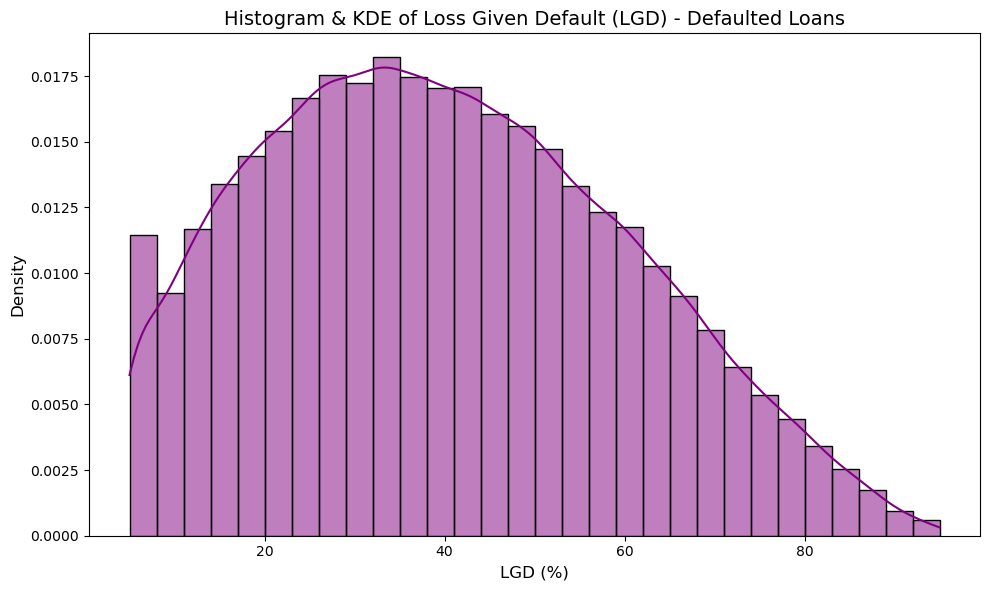

In [125]:
# 3. Plot the Histogram with KDE overlay
plt.figure(figsize=(10, 6))
sns.histplot(defaulted_data, bins=30, kde=True, color='purple', stat='density')

plt.title('Histogram & KDE of Loss Given Default (LGD) - Defaulted Loans', fontsize=14)
plt.xlabel('LGD (%)', fontsize=12)
plt.ylabel('Density', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# I

In [126]:
# 1. Get the data and drop any blank rows
scatter_data = master_df[['cibil_score', 'lgd_pct']].dropna()

In [127]:
# 2. Calculate the Pearson r (correlation)
pearson_r = scatter_data['cibil_score'].corr(scatter_data['lgd_pct'])

# Print the exact number for your written answer
print(f"Pearson r: {pearson_r:.2f}")

Pearson r: -0.04


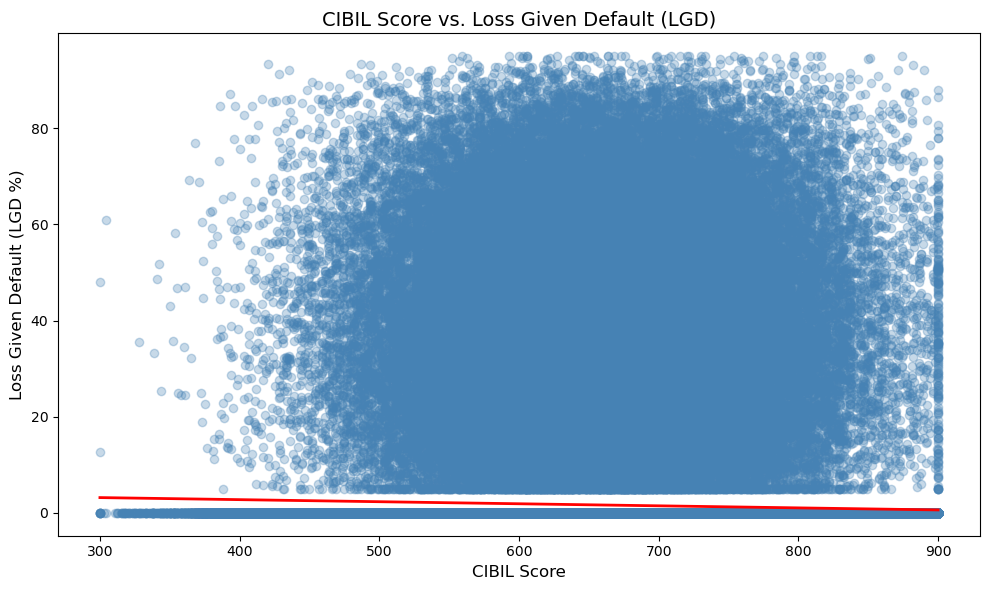

In [128]:
# 3. Plot the Scatter Plot with a Regression Line
plt.figure(figsize=(10, 6))

# scatter_kws controls the dots, line_kws controls the fitted line
sns.regplot(x='cibil_score', y='lgd_pct', data=scatter_data, 
            scatter_kws={'alpha': 0.3, 'color': 'steelblue'}, 
            line_kws={'color': 'red', 'linewidth': 2})

plt.title('CIBIL Score vs. Loss Given Default (LGD)', fontsize=14)
plt.xlabel('CIBIL Score', fontsize=12)
plt.ylabel('Loss Given Default (LGD %)', fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
# QUESTION 3   FEATURE ENGINEERING

In [ ]:
# a

In [129]:
# 1. Find the exact CPI column name (usually 'cpi_inflation_pct' or 'cpi_pct')
cpi_col = [col for col in master_df.columns if 'cpi' in col.lower() or 
           'inflation' in col.lower()][0]

In [130]:
# 2. Construct the four new features using the exact formulas
master_df['emi_to_income_ratio'] = master_df['installment_inr'] / (master_df['annual_inc_inr'] / 12)
master_df['loan_to_income_ratio'] = master_df['loan_amnt_inr'] / master_df['annual_inc_inr']
master_df['rate_spread_pct'] = master_df['int_rate_pct'] - master_df['rbi_repo_rate_pct']
master_df['real_interest_rate'] = master_df['int_rate_pct'] - master_df[cpi_col]

# Store feature names in a list
new_features = ['emi_to_income_ratio', 'loan_to_income_ratio', 'rate_spread_pct', 'real_interest_rate']

/var/folders/wq/qny254f95pzb62gc0tkv2vcc0000gn/T/ipykernel_1722/2839901989.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master_df['loan_to_income_ratio'] = master_df['loan_amnt_inr'] / master_df['annual_inc_inr']
/var/folders/wq/qny254f95pzb62gc0tkv2vcc0000gn/T/ipykernel_1722/2839901989.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  master_df['real_interest_rate'] = master_df['int_rate_pct'] - master_df[cpi_col]


In [131]:
# 3. Verify the output with .describe()
print("--- Verify Output (.describe) ---")
display(master_df[new_features].describe().round(4))

--- Verify Output (.describe) ---


,emi_to_income_ratio,loan_to_income_ratio,rate_spread_pct,real_interest_rate
count,1.959934e+06,1.959934e+06,2.000000e+06,2.000000e+06
mean,2.147000e-01,5.516000e-01,7.424300e+00,7.639800e+00
std,3.301000e-01,7.458000e-01,4.524000e+00,4.809200e+00
min,5.000000e-04,2.500000e-03,-1.000000e+00,-3.900000e+00
25%,5.220000e-02,1.479000e-01,3.920000e+00,4.150000e+00
50%,1.140000e-01,3.134000e-01,6.770000e+00,7.110000e+00
75%,2.458000e-01,6.515000e-01,1.042000e+01,1.081000e+01
max,2.858450e+01,3.385820e+01,2.400000e+01,2.460000e+01


In [132]:
# 4. Compute Pearson correlation with lgd_pct
print("\n--- Correlation with lgd_pct ---")
correlations = {}
for feat in new_features:
    corr = master_df[feat].corr(master_df['lgd_pct'])
    correlations[feat] = corr
    print(f"{feat}: {corr:.4f}")


--- Correlation with lgd_pct ---
emi_to_income_ratio: 0.0054
loan_to_income_ratio: 0.0026
rate_spread_pct: 0.0795
real_interest_rate: 0.0734


In [133]:
# 5. Identify the strongest correlation (using absolute values)
strongest_feature = max(correlations, key=lambda k: abs(correlations[k]))
print(f"\nStrongest Correlation with LGD: {strongest_feature}")


Strongest Correlation with LGD: rate_spread_pct


In [ ]:
# b

In [139]:
# 1. Construct the three new bureau features using the exact column names
master_df = master_df.copy()
master_df['credit_util_composite'] = (0.5 * master_df['revol_util_pct']) + \
                                     (0.3 * master_df['bc_util_pct']) + \
                                     (0.2 * master_df['all_util_pct'])

In [140]:
# We use np.maximum to ensure the denominator is at least 1 (prevents dividing by zero!)
master_df['delinq_severity_score'] = master_df['delinq_2yrs'] * (1 + 1 / np.maximum(master_df['mths_since_last_delinq'], 1))

master_df['enq_velocity_score'] = (master_df['num_enquiries_30d'] * 4) + master_df['num_enquiries_90d']

new_bureau_features = ['credit_util_composite', 'delinq_severity_score', 'enq_velocity_score']

In [141]:
# 2. Verify the output with .describe()
print("--- Verify Output (.describe) ---")
display(master_df[new_bureau_features].describe().round(4))

--- Verify Output (.describe) ---


,credit_util_composite,delinq_severity_score,enq_velocity_score
count,1.642578e+06,1.899793e+06,2.000000e+06
mean,4.057230e+01,1.163900e+00,8.246200e+00
std,1.218460e+01,1.772900e+00,7.912300e+00
min,3.800000e+00,0.000000e+00,0.000000e+00
25%,3.170000e+01,0.000000e+00,2.000000e+00
50%,4.006000e+01,0.000000e+00,6.000000e+00
75%,4.896000e+01,2.087000e+00,1.200000e+01
max,9.082000e+01,1.400000e+01,3.900000e+01


In [142]:
# 3. Compute Pearson correlation with lgd_pct
print("\n--- Correlation with lgd_pct ---")
for feat in new_bureau_features:
    corr = master_df[feat].corr(master_df['lgd_pct'])
    print(f"{feat}: {corr:.4f}")


--- Correlation with lgd_pct ---
credit_util_composite: 0.0040
delinq_severity_score: 0.0180
enq_velocity_score: 0.0005


In [ ]:
# c 

In [143]:
# 1. Construct the three new income and collateral features
master_df['income_stability_ratio'] = master_df['annual_inc_inr'] / (master_df['emp_length_years'] + 1)

master_df['credit_depth_score'] = master_df['total_acc'] / (master_df['credit_hist_years'] + 1)

master_df['collateral_coverage_ratio'] = master_df['collateral_value_inr'] / (master_df['loan_amnt_inr'] + 1)

new_income_features = ['income_stability_ratio', 'credit_depth_score', 'collateral_coverage_ratio']

In [144]:
# 2. Verify the output with .describe()
print("--- Verify Output (.describe) ---")
display(master_df[new_income_features].describe().round(4))

--- Verify Output (.describe) ---


,income_stability_ratio,credit_depth_score,collateral_coverage_ratio
count,1.959934e+06,2.000000e+06,2.000000e+06
mean,1.439370e+05,2.072200e+00,4.750500e+00
std,2.355584e+05,1.948900e+00,1.321250e+01
min,2.777778e+03,2.860000e-02,0.000000e+00
25%,3.263423e+04,9.064000e-01,0.000000e+00
50%,7.181423e+04,1.420700e+00,0.000000e+00
75%,1.603417e+05,2.463100e+00,2.435200e+00
max,1.818182e+07,1.766670e+01,4.562713e+02


In [145]:
# 3. Compute Pearson correlation with lgd_pct
print("\n--- Correlation with lgd_pct ---")
for feat in new_income_features:
    corr = master_df[feat].corr(master_df['lgd_pct'])
    print(f"{feat}: {corr:.4f}")


--- Correlation with lgd_pct ---
income_stability_ratio: -0.0032
credit_depth_score: 0.0001
collateral_coverage_ratio: -0.0000


In [146]:
# d

In [147]:
# 1. Calculate skewness BEFORE transformation
skew_inc_before = master_df['annual_inc_inr'].skew()
skew_loan_before = master_df['loan_amnt_inr'].skew()

print("--- Skewness BEFORE Transformation ---")
print(f"annual_inc_inr: {skew_inc_before:.4f}")
print(f"loan_amnt_inr: {skew_loan_before:.4f}")

--- Skewness BEFORE Transformation ---
annual_inc_inr: 4.6758
loan_amnt_inr: 3.6511


In [148]:
# 2. Apply log(1 + x) transformation
master_df['log_annual_inc'] = np.log1p(master_df['annual_inc_inr'])
master_df['log_loan_amnt'] = np.log1p(master_df['loan_amnt_inr'])

In [149]:
# 3. Calculate skewness AFTER transformation
skew_inc_after = master_df['log_annual_inc'].skew()
skew_loan_after = master_df['log_loan_amnt'].skew()

print("\n--- Skewness AFTER Transformation ---")
print(f"log_annual_inc: {skew_inc_after:.4f}")
print(f"log_loan_amnt: {skew_loan_after:.4f}")


--- Skewness AFTER Transformation ---
log_annual_inc: 0.3287
log_loan_amnt: 0.5816


In [150]:
# e

In [151]:
# 1. Create the binary COVID flag (1 if year is 2020, 0 otherwise)
master_df['covid_issue_year_flag'] = (master_df['issue_year'] == 2020).astype(int)

In [152]:
# 2. Grouped summary of mean lgd_pct
summary = master_df.groupby('covid_issue_year_flag')['lgd_pct'].mean()
print("--- Mean LGD (%) by COVID Flag ---")
print(summary.round(2))

--- Mean LGD (%) by COVID Flag ---
covid_issue_year_flag
0    1.54
1    1.79
Name: lgd_pct, dtype: float32


In [156]:
# 3. Independent-samples t-test
# We separate the two groups and drop empty rows so the math works
group_0 = master_df[master_df['covid_issue_year_flag'] == 0]['lgd_pct'].dropna()
group_1 = master_df[master_df['covid_issue_year_flag'] == 1]['lgd_pct'].dropna()

# Run the t-test (using Welch's t-test which is safer for unequal group sizes)
t_stat, p_value = stats.ttest_ind(group_0, group_1, equal_var=False)

print(f"\n--- T-Test Results ---")
print(f"P-Value: {p_value:.5f}")

if p_value < 0.05:
    print("Conclusion: The difference IS statistically significant (p < 0.05).")
else:
    print("Conclusion: The difference is NOT statistically significant (p >= 0.05).")


--- T-Test Results ---
P-Value: 0.00000
Conclusion: The difference IS statistically significant (p < 0.05).


In [ ]:
# QUESTION 5   BUSINESS RECOMMENDATIONS

In [ ]:
'''To reduce defaults, the bank must combine CIBIL scores with recent delinquency checks, 
strictly cap EMI-to-income ratios, and restrict automatic approvals for low-grade loans. 
Additionally, they should charge higher interest rates for risky loan purposes and mandate 
collateral for borrowers with unstable job histories.'''